# **TRADUCCIÓN DE IMÁGENES DÍA<->NOCHE MEDIANTE CycleGAN**

In [ ]:
!pip install -q kagglehub

import kagglehub
import os
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import time
import numpy as np
from IPython.display import clear_output
from tensorflow.keras import layers, Model
from tensorflow.keras import mixed_precision
import pathlib

## Descarga y preparación del dataset

In [ ]:
#  Descargar dataset Night-to-Day

dataset_path = kagglehub.dataset_download("kareem00ali/night-to-day")
print("Dataset descargado en:", dataset_path)

100%|██████████| 3.86G/3.86G [00:40<00:00, 103MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/kareem00ali/night-to-day/versions/3


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
BASE_DIR = os.path.join(dataset_path, "night_to_day")
trainA = os.path.join(BASE_DIR, "trainA")
trainB = os.path.join(BASE_DIR, "trainB")
testA  = os.path.join(BASE_DIR, "testA")
testB  = os.path.join(BASE_DIR, "testB")

In [ ]:
# Para hacer los cálculos en float16 (acelera el rendimiento)

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

In [ ]:
# Parámetros

IMAGE_SIZE = 128
BATCH_SIZE = 16
BUFFER_SIZE = 1000
OUTPUT_CHANNELS = 3
LAMBDA = 15
EPOCHS = 200
MAX_IMAGES = 2000
CHECKPOINT_DIR = "/content/drive/MyDrive/Trabajo_Grupal_MG/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Guardando checkpoints en:", CHECKPOINT_DIR)

Guardando checkpoints en: /content/drive/MyDrive/Trabajo_Grupal_MG/checkpoints


In [ ]:
# Funciones de preprocesamiento

def normalize(image):
    image = tf.cast(image, tf.float32)
    return (image / 127.5) - 1.0  # [-1,1]

def load_dataset(folder_path, max_images=MAX_IMAGES):
    if not os.path.exists(folder_path):
        print("Warning: carpeta no encontrada:", folder_path)
        # Retornar dataset vacío para evitar crash
        return tf.data.Dataset.from_tensor_slices(np.zeros((0, IMAGE_SIZE, IMAGE_SIZE, 3))).batch(BATCH_SIZE)
    ds = tf.keras.utils.image_dataset_from_directory(
        folder_path,
        labels=None,
        image_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    ds = ds.unbatch()
    if max_images is not None:
        ds = ds.take(max_images)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.map(lambda x: normalize(x), num_parallel_calls=tf.data.AUTOTUNE)
    return ds

train_day = load_dataset(trainA)
train_night = load_dataset(trainB)
full_train = tf.data.Dataset.zip((train_day, train_night))
full_train = full_train.shuffle(BUFFER_SIZE).prefetch(tf.data.AUTOTUNE)

Found 32821 files.
Found 24595 files.


## Arquitectura del modelo

In [ ]:
# Generadores

def resnet_block(x, filters, size=3):
    init = x
    x = layers.Conv2D(filters, size, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, size, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.add([x, init])
    return x

def create_generator(image_size=(IMAGE_SIZE, IMAGE_SIZE, 3), n_resnet=9):
    inputs = layers.Input(shape=image_size)
    x = layers.Conv2D(64, 7, padding='same')(inputs)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)

    # Downsampling
    x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(256, 3, strides=2, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)

    # ResNet blocks
    for _ in range(n_resnet):
        x = resnet_block(x, 256)

    # Upsampling
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(3, 7, padding='same', activation='tanh')(x)
    return Model(inputs, x, name="ResNet_Generator")

generator_g = create_generator()  # dia -> noche
generator_f = create_generator()  # noche -> dia
generator_g.summary()

Model: "ResNet_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (GroupNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ group_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     73,856 │ re_lu[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (GroupNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 64, 64,    │          0 │ group_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    295,168 │ re_lu_1[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (GroupNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ group_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │    590,080 │ re_lu_2[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_3[0][0]    │
│ (GroupNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ group_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    590,080 │ re_lu_3[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]    │
│ (GroupNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ group_normalizat… │
│                     │ 256)              │            │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ add[0][0]       

 Total params: 11,388,675 (43.44 MB)

 Trainable params: 11,388,675 (43.44 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Discriminadores

def create_discriminator(image_size=(IMAGE_SIZE, IMAGE_SIZE, 3)):
    inputs = layers.Input(shape=image_size)
    x = layers.Conv2D(64, 4, strides=2, padding='same')(inputs)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, 4, strides=2, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256, 4, strides=2, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(512, 4, strides=1, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(1, 4, strides=1, padding='same')(x)  # Patch output
    return Model(inputs, x, name="PatchGAN_Discriminator")

discriminator_x = create_discriminator()  # domain A (day)
discriminator_y = create_discriminator()  # domain B (night)
discriminator_x.summary()


Model: "PatchGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 64, 64, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 32, 32, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_46          │ (None, 32, 32, 128)    │           256 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 16, 16, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_47          │ (None, 16, 16, 256)    │           512 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 512)    │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_48          │ (None, 16, 16, 512)    │         1,024 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 16, 16, 1)      │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,766,529 (10.55 MB)

 Trainable params: 2,766,529 (10.55 MB)

 Non-trainable params: 0 (0.00 B)

## Definición de pérdidas

In [ ]:
# Pérdidas y optimizadores
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real, generated):
    real_loss = loss_obj(tf.ones_like(real), real)
    generated_loss = loss_obj(tf.zeros_like(generated), generated)
    return 0.5 * (real_loss + generated_loss)

def generator_loss(generated):
    return loss_obj(tf.ones_like(generated), generated)

def cycle_loss(real_image, cycled_image):
    cycled_image = tf.cast(cycled_image, real_image.dtype)
    loss = tf.reduce_mean(tf.abs(real_image - cycled_image))
    return LAMBDA * loss

def identity_loss(real_image, same_image):
    same_image = tf.cast(same_image, real_image.dtype)
    loss = tf.reduce_mean(tf.abs(real_image - same_image))
    return LAMBDA * 0.3 * loss

generator_g_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
generator_f_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_x_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_y_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

## Entrenamiento del modelo

In [ ]:
# Checkpoints
epoch_var = tf.Variable(0, dtype=tf.int64, name='epoch')
ckpt = tf.train.Checkpoint(generator_g=generator_g,
                           generator_f=generator_f,
                           discriminator_x=discriminator_x,
                           discriminator_y=discriminator_y,
                           generator_g_opt=generator_g_opt,
                           generator_f_opt=generator_f_opt,
                           discriminator_x_opt=discriminator_x_opt,
                           discriminator_y_opt=discriminator_y_opt,
                           epoch=epoch_var)
ckpt_manager = tf.train.CheckpointManager(ckpt, CHECKPOINT_DIR, max_to_keep=5)

initial_epoch = 0
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    initial_epoch = int(epoch_var.numpy())
    print(f"Checkpoint restaurado: {ckpt_manager.latest_checkpoint}")
    print(f"Continuando desde época {initial_epoch + 1}")
else:
    print("No hay checkpoints en el drive - entrenamiento empezará desde cero.")

Checkpoint restaurado: /content/drive/MyDrive/Trabajo_Grupal_MG/checkpoints/ckpt-109
Continuando desde época 110


In [ ]:
# Función para mostrar imágenes
def generate_images(model, test_input, title_prefix=""):
    if test_input is None:
        print("No hay muestras para mostrar (dataset vacío).")
        return
    prediction = model(test_input, training=False)
    prediction = tf.cast(prediction, tf.float32)
    plt.figure(figsize=(8,8))
    display_list = [test_input[0], prediction[0]]
    title = [f'{title_prefix}Input', f'{title_prefix}Predicted']
    for i in range(2):
        plt.subplot(1, 2, i+1)
        plt.title(title[i])
        plt.imshow((display_list[i] + 1) * 0.5)
        plt.axis('off')
    plt.show()


In [ ]:
# Train step
@tf.function
def train_step(real_day, real_night):
    with tf.GradientTape(persistent=True) as tape:
        # Generar falsos y ciclos
        fake_night = generator_g(real_day, training=True)
        cycled_day = generator_f(fake_night, training=True)

        fake_day = generator_f(real_night, training=True)
        cycled_night = generator_g(fake_day, training=True)

        # Identity mapping
        same_day = generator_f(real_day, training=True)
        same_night = generator_g(real_night, training=True)

        # Discriminadores
        disc_real_day = discriminator_x(real_day, training=True)
        disc_real_night = discriminator_y(real_night, training=True)

        disc_fake_day = discriminator_x(fake_day, training=True)
        disc_fake_night = discriminator_y(fake_night, training=True)

        # Pérdidas
        gen_g_adv_loss = generator_loss(disc_fake_night)
        gen_f_adv_loss = generator_loss(disc_fake_day)

        cyc_loss = cycle_loss(real_day, cycled_day) + cycle_loss(real_night, cycled_night)
        id_loss = identity_loss(real_night, same_night) + identity_loss(real_day, same_day)

        total_gen_g_loss = gen_g_adv_loss + cyc_loss + id_loss
        total_gen_f_loss = gen_f_adv_loss + cyc_loss + id_loss

        disc_x_loss = discriminator_loss(disc_real_day, disc_fake_day)
        disc_y_loss = discriminator_loss(disc_real_night, disc_fake_night)

    # Gradientes y aplicación
    gen_g_grads = tape.gradient(total_gen_g_loss, generator_g.trainable_variables)
    gen_f_grads = tape.gradient(total_gen_f_loss, generator_f.trainable_variables)

    disc_x_grads = tape.gradient(disc_x_loss, discriminator_x.trainable_variables)
    disc_y_grads = tape.gradient(disc_y_loss, discriminator_y.trainable_variables)

    generator_g_opt.apply_gradients(zip(gen_g_grads, generator_g.trainable_variables))
    generator_f_opt.apply_gradients(zip(gen_f_grads, generator_f.trainable_variables))
    discriminator_x_opt.apply_gradients(zip(disc_x_grads, discriminator_x.trainable_variables))
    discriminator_y_opt.apply_gradients(zip(disc_y_grads, discriminator_y.trainable_variables))

    return {
        "g_g_loss": total_gen_g_loss,
        "g_f_loss": total_gen_f_loss,
        "dx_loss": disc_x_loss,
        "dy_loss": disc_y_loss
    }


Epoch 109 - tiempo: 151.55s
Resumen de Pérdidas (último batch):
  - Generador G (Día->Noche): 2.7222
  - Generador F (Noche->Día): 2.2689
  - Discriminador X (Día):     0.2421
  - Discriminador Y (Noche):   0.1975

Ejemplo Day → Night:


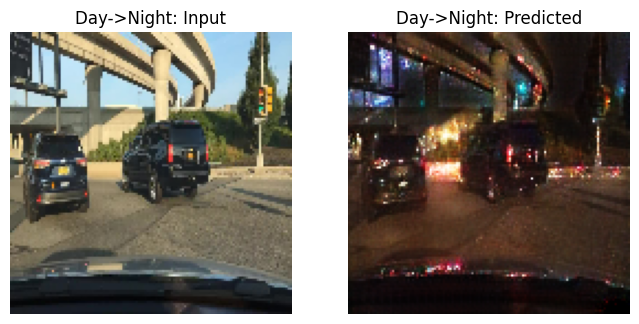


Ejemplo Night → Day:


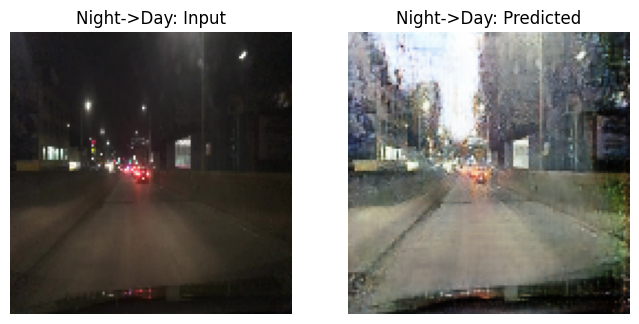

Checkpoint guardado en: /content/drive/MyDrive/Trabajo_Grupal_MG/checkpoints/ckpt-109

===== EPOCH 110/200 =====


In [ ]:
# Entrenamiento (bucle principal)
sample_day = next(iter(train_day.take(1)))
sample_night = next(iter(train_night.take(1)))

for epoch in range(initial_epoch, EPOCHS):
    start = time.time()
    print(f"\n===== EPOCH {epoch+1}/{EPOCHS} =====")
    n = 0

    for day_batch, night_batch in full_train:
        losses = train_step(day_batch, night_batch)
        if n % 20 == 0:
            print('.', end='', flush=True)
        n += 1

    clear_output(wait=True)
    print(f"\nEpoch {epoch+1} - tiempo: {time.time()-start:.2f}s")
    print("Resumen de Pérdidas (último batch):")
    print(f"  - Generador G (Día->Noche): {losses['g_g_loss']:.4f}")
    print(f"  - Generador F (Noche->Día): {losses['g_f_loss']:.4f}")
    print(f"  - Discriminador X (Día):     {losses['dx_loss']:.4f}")
    print(f"  - Discriminador Y (Noche):   {losses['dy_loss']:.4f}")

    # Mostrar imágenes ejemplo
    if sample_day is not None:
        print("\nEjemplo Day → Night:")
        generate_images(generator_g, sample_day, title_prefix="Day->Night: ")

    if sample_night is not None:
        print("\nEjemplo Night → Day:")
        generate_images(generator_f, sample_night, title_prefix="Night->Day: ")

    # Guardar checkpoint en Drive
    epoch_var.assign(epoch + 1)
    ckpt_save_path = ckpt_manager.save()
    print("Checkpoint guardado en:", ckpt_save_path)


In [ ]:
def load_image_for_inference(path):
    img = Image.open(path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = np.array(img).astype(np.float32)
    arr_norm = (arr / 127.5) - 1.0
    return np.expand_dims(arr_norm, axis=0)

def translate_image_both(img_path):
    arr_batch = load_image_for_inference(img_path)

    pred_day2night = generator_g(arr_batch, training=False)[0].numpy()
    pred_night2day = generator_f(arr_batch, training=False)[0].numpy()

    plt.figure(figsize=(18,6))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow((arr_batch[0] + 1) * 0.5)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Día -> Noche")
    plt.imshow((pred_day2night + 1) * 0.5)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Noche -> Día")
    plt.imshow((pred_night2day + 1) * 0.5)
    plt.axis("off")

    plt.show()

# Subir imagen y traducir
print("Sube una imagen para traducir a día y noche:")
uploaded = files.upload()

if uploaded:
    img_path = list(uploaded.keys())[0]
    print("Imagen subida:", img_path)
    translate_image_both(img_path)

## Evaluación

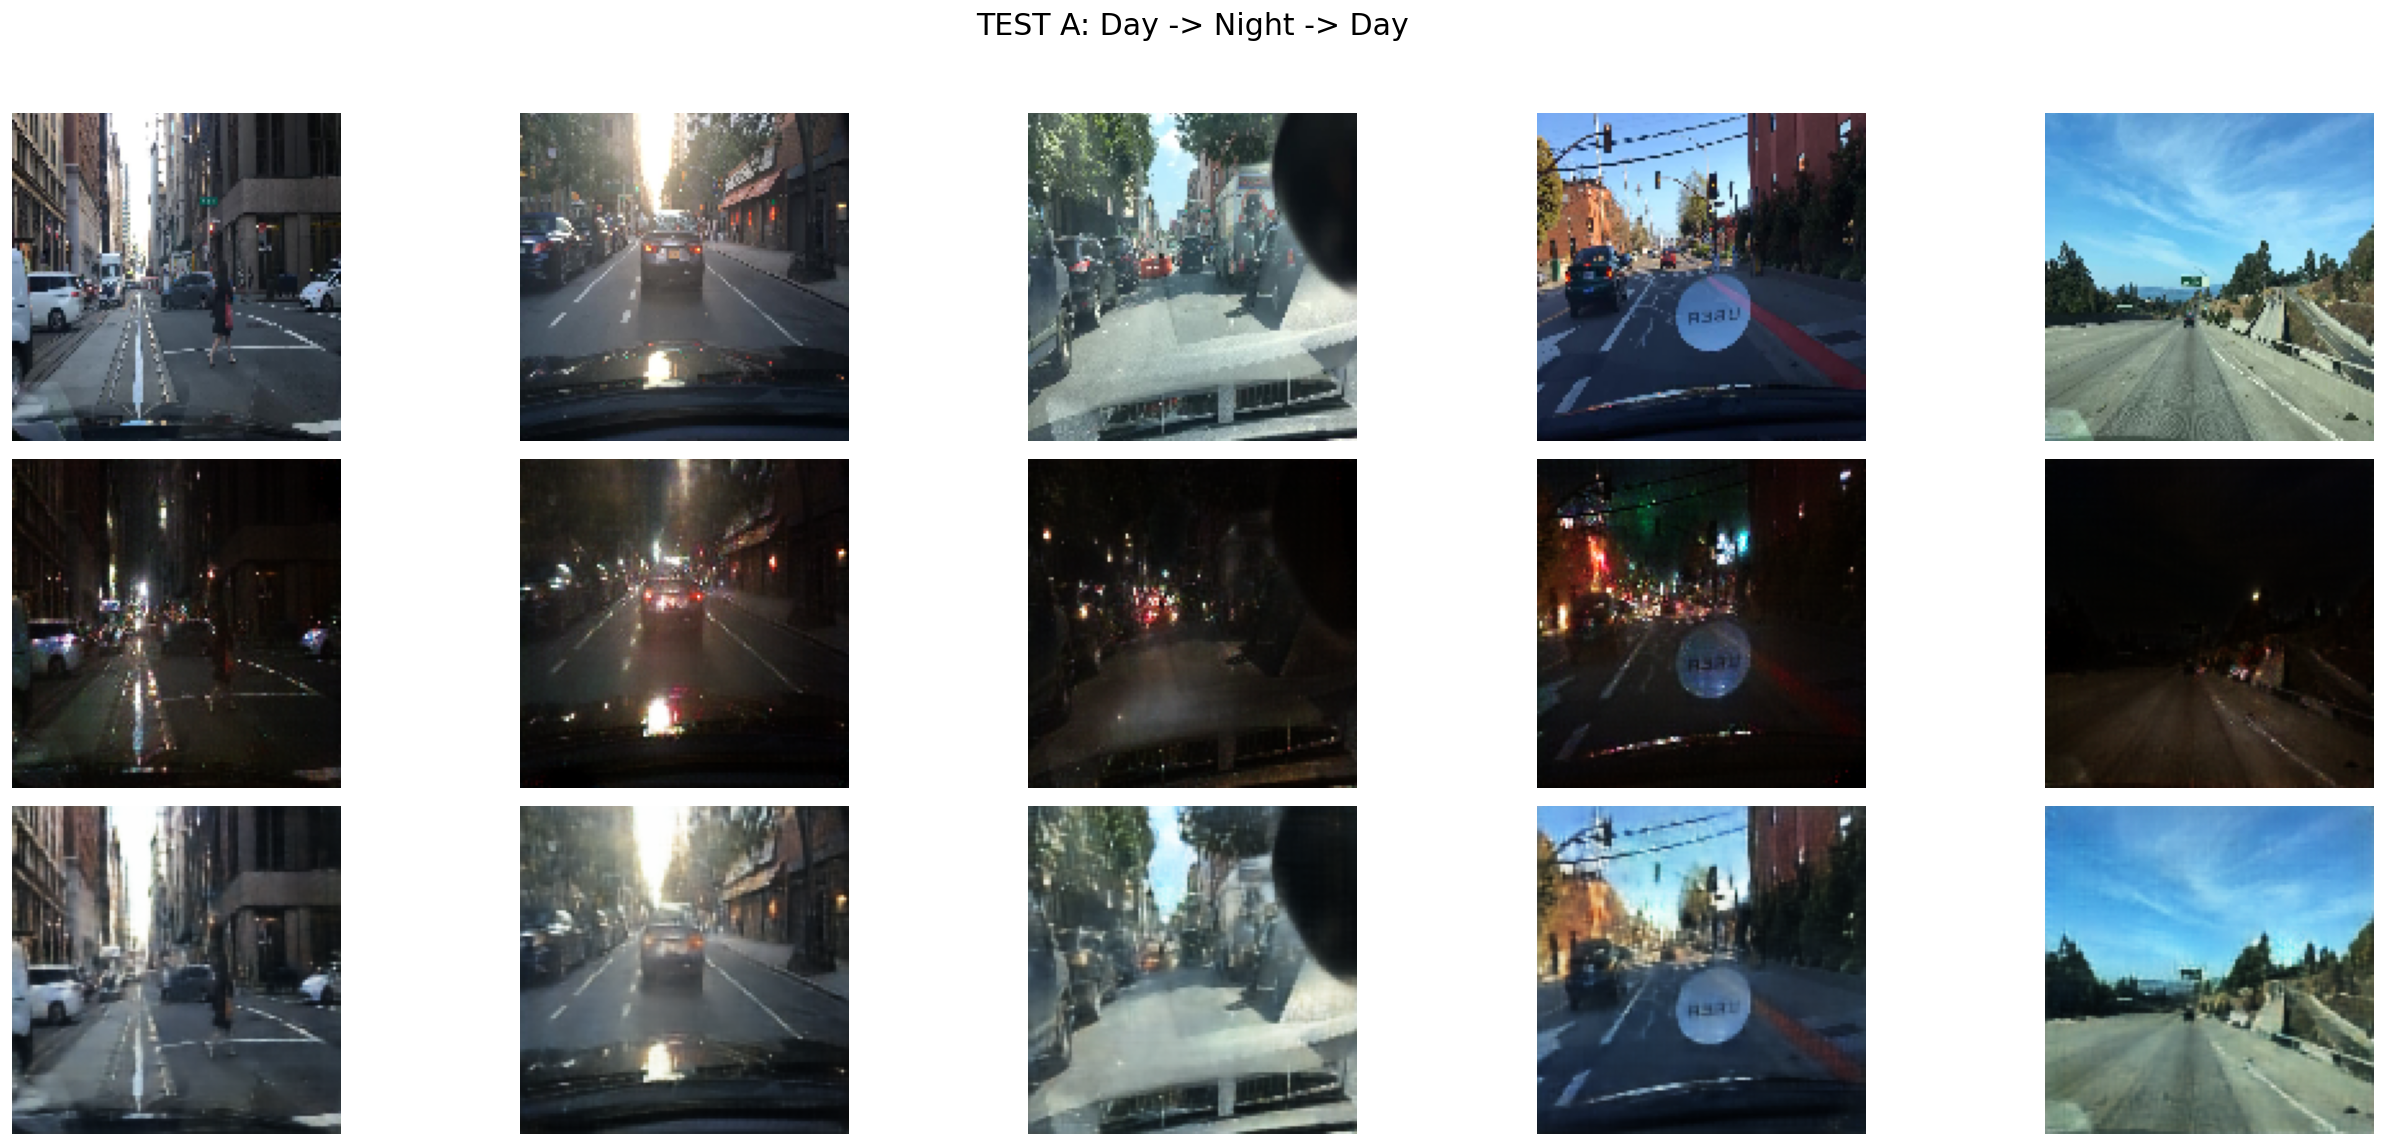

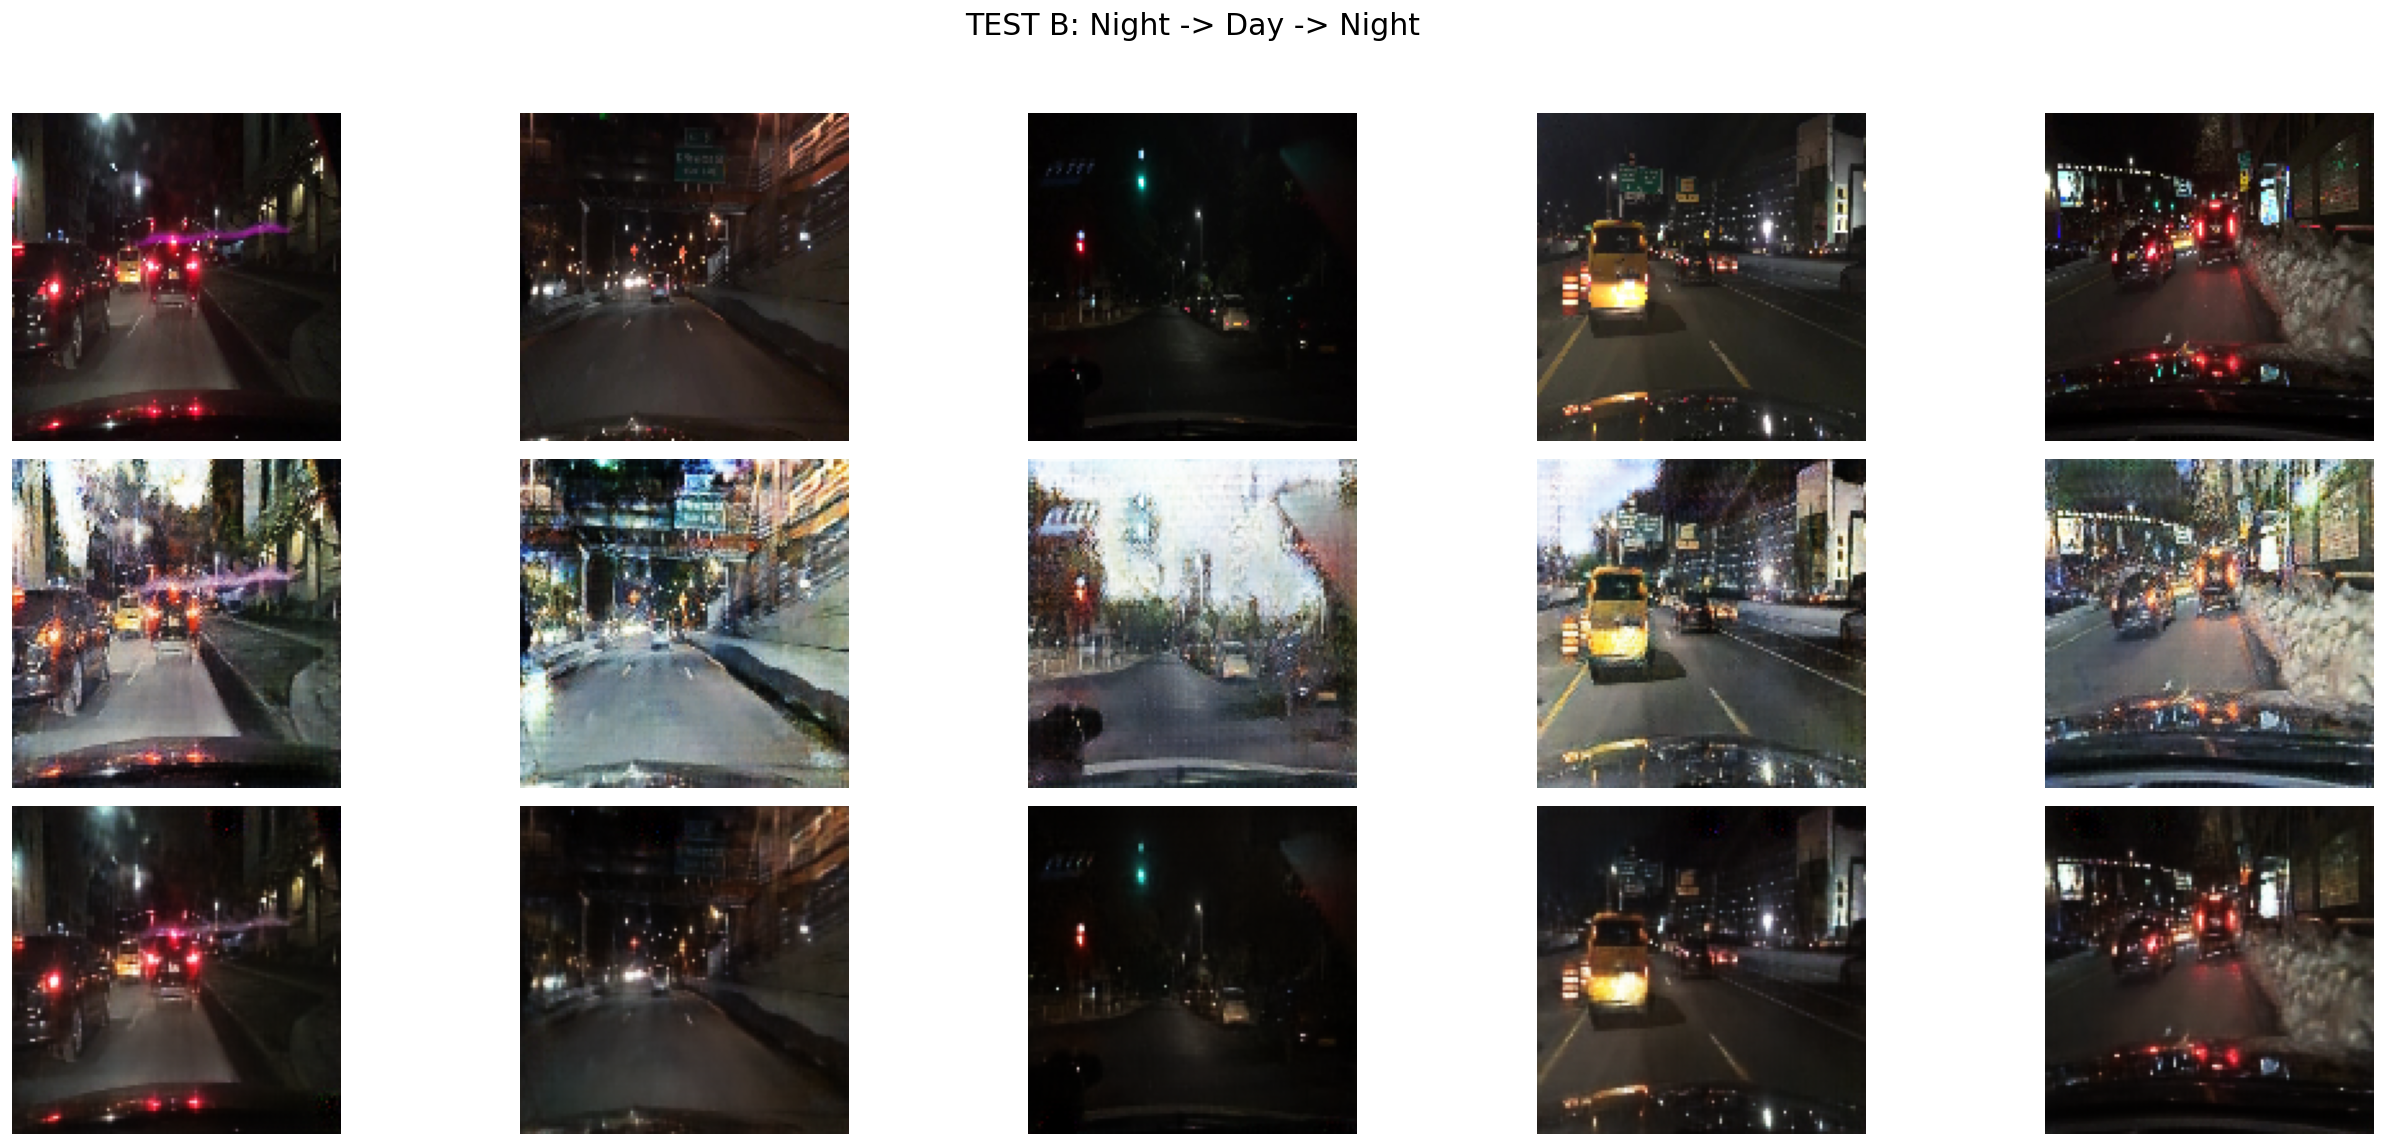

In [ ]:
def load_random_images(folder_path, n=5):
    files = list(pathlib.Path(folder_path).glob('*'))
    files = np.random.choice(files, n, replace=False)

    images = []
    for f in files:
        img = tf.keras.utils.load_img(f, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = tf.keras.utils.img_to_array(img)
        img = normalize(img)
        images.append(img)

    return tf.stack(images)

test_day_imgs = load_random_images(testA, n=5)
test_night_imgs = load_random_images(testB, n=5)

# Day -> Night -> Day
fake_night = generator_g(test_day_imgs, training=False)
cycled_day = generator_f(fake_night, training=False)

# Night -> Day -> Night
fake_day = generator_f(test_night_imgs, training=False)
cycled_night = generator_g(fake_day, training=False)

def show_cycle_results(original, translated, cycled, title):
    plt.figure(figsize=(22, 10), dpi=120)

    for i in range(5):
        # Original
        ax = plt.subplot(3, 5, i + 1)
        ax.imshow((original[i] + 1) * 0.5)
        ax.axis("off")
        if i == 0:
            ax.set_ylabel("Original", fontsize=14)

        # Traducida
        ax = plt.subplot(3, 5, i + 6)
        ax.imshow((translated[i] + 1) * 0.5)
        ax.axis("off")
        if i == 0:
            ax.set_ylabel("Traducida", fontsize=14)

        # Reconstruida
        ax = plt.subplot(3, 5, i + 11)
        ax.imshow((cycled[i] + 1) * 0.5)
        ax.axis("off")
        if i == 0:
            ax.set_ylabel("Ciclo", fontsize=14)

    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

show_cycle_results(
    test_day_imgs,
    fake_night,
    cycled_day,
    title="TEST A: Day -> Night -> Day"
)

show_cycle_results(
    test_night_imgs,
    fake_day,
    cycled_night,
    title="TEST B: Night -> Day -> Night"
)

# **DayNightImageTranslator**

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from google.colab import drive, files
import matplotlib.pyplot as plt
import PIL.Image

In [3]:
# Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# PArámetros
IMAGE_SIZE = 128
CHECKPOINT_DIR = "/content/drive/MyDrive/Trabajo_Grupal_Metodos_Generativos/Trabajo_Grupal_MG_checkpoint"
CKPT_NAME = "Copia de ckpt-109"

In [5]:
# Generadores
def resnet_block(x, filters, size=3):
    init = x
    x = layers.Conv2D(filters, size, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, size, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.add([x, init])
    return x

def create_generator(image_size=(IMAGE_SIZE, IMAGE_SIZE, 3), n_resnet=9):
    inputs = layers.Input(shape=image_size)
    x = layers.Conv2D(64, 7, padding='same')(inputs)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)

    # Downsampling
    x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(256, 3, strides=2, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)

    # ResNet blocks
    for _ in range(n_resnet):
        x = resnet_block(x, 256)

    # Upsampling
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same')(x)
    x = layers.GroupNormalization(groups=-1)(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(3, 7, padding='same', activation='tanh')(x)
    return Model(inputs, x, name="ResNet_Generator")

generator_g = create_generator()  # dia -> noche
generator_f = create_generator()  # noche -> dia

In [6]:
# Cargar checkpoints
if not os.path.exists(CHECKPOINT_DIR):
    raise FileNotFoundError(f"No se encontró la carpeta de checkpoints:\n{CHECKPOINT_DIR}")

ckpt_path = os.path.join(CHECKPOINT_DIR, CKPT_NAME)

ckpt = tf.train.Checkpoint(generator_g=generator_g, generator_f=generator_f)
ckpt.restore(ckpt_path).expect_partial()
print("Checkpoint cargado correctamente.")

Checkpoint cargado correctamente.


In [7]:
# Funciones de utilidad

def load_image(path):
    img = PIL.Image.open(path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = np.array(img).astype(np.float32)
    arr_norm = (arr / 127.5) - 1.0
    return np.expand_dims(arr_norm, axis=0), img

def show_image(image, title=None):
    img = (image[0] + 1) * 0.5
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

In [8]:
# Traducción con detección automática
def translate_image_model_based(img_path):
    arr_batch, img_orig = load_image(img_path)

    # Transformaciones
    fake_night = generator_g(arr_batch, training=False)
    fake_day = generator_f(arr_batch, training=False)

    # Reconstrucción ciclo
    recon_day = generator_f(fake_night, training=False)
    recon_night = generator_g(fake_day, training=False)

    # Magnitud de cambio
    change_to_night = tf.reduce_mean(tf.abs(fake_night - arr_batch))
    change_to_day = tf.reduce_mean(tf.abs(fake_day - arr_batch))

    # Detectar dominio
    if change_to_day > change_to_night:
        domain = "noche"
        pred = fake_day[0]
        cycle_img = recon_night[0]
        title_text = "Noche → Día"
    else:
        domain = "día"
        pred = fake_night[0]
        cycle_img = recon_day[0]
        title_text = "Día → Noche"

    # Visualización
    plt.figure(figsize=(18,6))
    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img_orig)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title(title_text)
    plt.imshow((pred + 1) * 0.5)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Reconstrucción del ciclo")
    plt.imshow((cycle_img + 1) * 0.5)
    plt.axis("off")
    plt.show()

    print(f"Dominio detectado por el modelo: {domain}")
    print(f"Magnitude cambio a noche: {change_to_night:.4f}, a día: {change_to_day:.4f}")


Sube una imagen para traducir a día o noche:


Saving dia2.png to dia2.png
Imagen subida: dia2.png


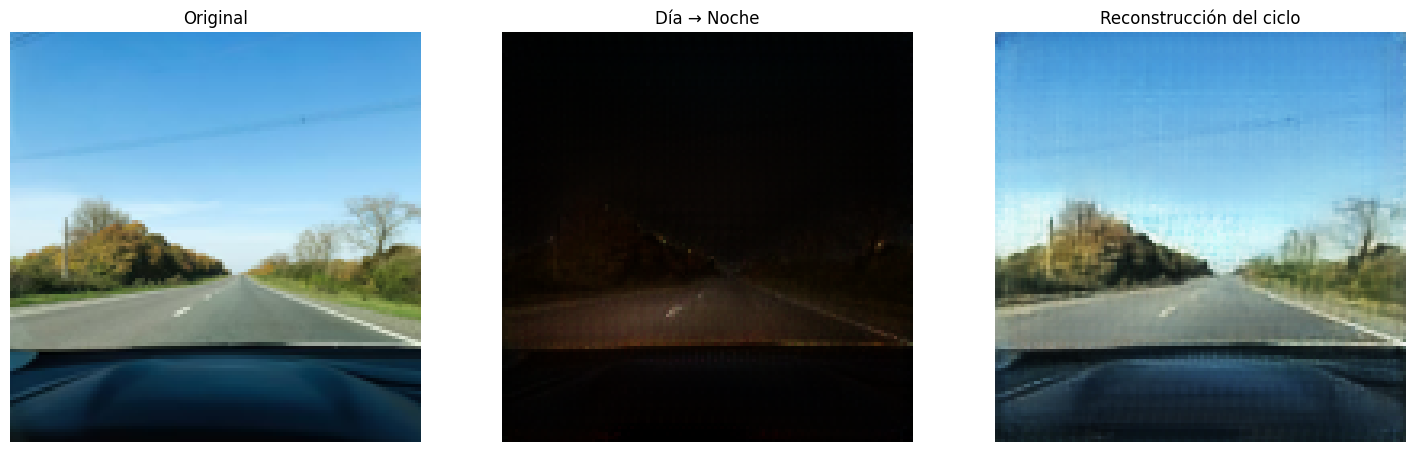

Dominio detectado por el modelo: día
Magnitude cambio a noche: 0.9519, a día: 0.0461


In [11]:
# Subida de imagen y traducción

print("Sube una imagen para traducir a día o noche:")
uploaded = files.upload()

if uploaded:
    img_path = list(uploaded.keys())[0]
    print("Imagen subida:", img_path)
    translate_image_model_based(img_path)